<a href="https://colab.research.google.com/github/ced-sys/AI-N-ML/blob/main/QuantumML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Install Qiskit
1. **Qiskit**
* Qiskit (Quantum Information Science Kit) is IBM's open-source SDK for quantum computing.
* It allows users to:
  * Create quantum circuits using Python.
  Simulate quantume computations locally or run them on real quantum hardware (via IBM Quatum services).
  * Visualize results, Blocj spheres, histograms, etc.
  * Analyze and optimize quantum algorithms

* It consists of several sub-modules (installed automatically with `qiskit`):
  * `qiskit.circuit`- For Building and manipulating quantum circuits.
  *`qiskit.transpiler`-For optimizing circuits for specific quantum hardware.
  * `qiskit.visualization`- For plotting circuits and simulation results.
  * `qiskit.providers`- For connecting to quantum simulators or real devices.

  2. **Qiskit Aer**
  `qiskit-aer`(Aer=Air in Latin, representing simulation) provides the simulation backend for Qiskit.
  
  * It allows you to:
    * Run-quantum circuits on your local computer without accessin a real quantum processor.
    * Use fast C++ based simulation for better performance.
    * Choose different simulation modes:
      * `statevector_simulator`-simulates the entire quantum state.
      * `qasm_simulator`- mimics how a real quantum computer measures qubits.
      * `unitary_simulator`-tracks the full unitary matrix for debugging and analysis
      * `density_matrix_simulator`-for mixed-state or noisy simulations.

In [ ]:
!pip install qiskit qiskit-aer

### Set up working environment

1. `from qiskit import QuantumCircuit, transpile`
* `QuantumCircuit`:
 * This is the core class in Qiskit used to define quantum circuits, the buildin blocks of any quantum program.

  * You use it to:

    * Create quantum registers (qubits) and classical registers (bit).
    * Apply quantum gates (like `X`, `H`, `CX`, etc.)
    * Add measurements to read the state of qubits.
  This circuit object can then be simulated or run on actual quantum hardware.

* `transpile`
* This function optimizes a quantum circuit to make it compatible with a specific backend (e.g, simulator or real quantum processor).
* This function optimizes a quantum circuit to make it compatible with a specific backend
* It:
  * Rearranges and simplifies gates.
  * Reduces noise by minmizing gate depth.
  * Converts circuit gates to match what the target device supports.

2. `from qiskit_aer import AerSimulator`
* The `AerSimulator` is the core simulation engine for running quantum circuits on your local runtime.

* Its part of the `qiskit-aer` package
* The simulator mimics quantum computation results withut requiring access to IBM Quantum hardware.

3. `from qiskit.visualization import plot_histogram, plot_bloch_multivector`
* `plot_histogram`
* Used to visualize measurement outcomes of a quantum circuit.
* `plot_bloch_multivector`
* Visualizes the state of qubits on a Bloc sphere, which shows the superposition and phase of a qubit in 3D.

4. `import matplotlib.pyplot as plt`
* Standard Python library for plotting.

5. `import numpy as np`
* NumPy is used for numerical operations, arrays and mathematical computations.



In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt
import numpy as np

### Quantum Circuit
1. `qc=QuantumCircuit(1, 1)`
* This line creates a new circuit named `qc`.
* The parameters `(1,1)` mean:
  * `1` quantum bit (qubit)-> represents the basic unit of quatum information.
  `1` classical bit-> Used to store measurement results from the qubit.

* So,you now have a 1-qubit, 1-classical bit circuit, the simplest possible setup in quantum computing.

2. `print(qc.draw(output='text))`
* This command draws the circuit layout in ASCII (text-based) form and prints it.
* The method `.draw()` provides different ways to visualize a quantum circuit:
  * `'text'`-> displays it as simple ASCII art in the notebook.
  * `'mpl'`-> returns a Matplotlib figure.
  * `'latex'`->renders in LaTeX if available.

* At this stage:
   * The qubit is in the |0> (ground state).
   * No operations (gates) are acting on it.
   * The classical bit is ready to record a measurement, but none has been made yet.
* This serves as the starting point before you add gates or measurements.

In [ ]:
qc=QuantumCircuit(1, 1)
print(qc.draw(output='text'))

     
  q: 
     
c: 1/
     


### Hadamard Gate
1. `qc.h(0)`
* This applies a Hadamard gate (`H` gate) to qubit 0 (the only qubit in the circuit).

**What the Hadamard Gate does**
* The Hadamard gate is one of the most fundamental quantum operations. It transforms the qubit from a definite state (|0> or |1>) into a superposition of both.

* Mathematically:
$$
H\lvert 0 \rangle=\frac{\lvert 0 \rangle +\lvert 1 \rangle}{\sqrt{2}}
$$

$$ H\lvert 1 \rangle=\frac{\lvert 0 \rangle- \lvert 1 \rangle}{\sqrt{2}} $$

* Before applying `H`: the qubit is definitely 0.
* After applying `H`: the qubit is in a 50/50 superposition, equal probability of being measured as 0 or 1.

2. `print(qc.draw(output='text'))`
* This draws the updated circuit, showing the new `H` gate applied to qubit 0.

The Hadamard gate is often used to:
* Initialize a qubit into superposition (start of many algorithms, like Grover's and Shor's).
* Creat interference patterns when combined with other gates.
* Explore quantum parallelism, where multiple states are processed simultaneously.

In [ ]:
qc.h(0)
print(qc.draw(output='text'))

     ┌───┐
  q: ┤ H ├
     └───┘
c: 1/═════
          


### Measurement

1. `qc.measure(0, 0)`
* This line measures the qubit (`0`) and stores the result in the classical bit (`0`).

* The first argument (`0`)-> refers to the quantum bit being measured.
* The second argument (`0`) -> refers to the classical bit where the result is stored.

**What the measurement does**
* Measurement is not like normal observation, it's a collapse of the qubit's superposition into a definite state.

* Once measured:
  * The quantum superposition collapses, you can't get it back.
  * The measured value (0 or 1) is stired in the classical register `c_0`.

  2. `print(qc.draw(output='text'))`
  * This displays the final circuit, now including both the Hadamard gate and the measurement.
  **Output**
  * The `H` box: Hadamard gate on qubit 0.
  * The `M` box: Measurement operation.
  * The arrow (`╩` and `0`) indicates the measurement result being sent to classical bit 0.


In [ ]:
qc.measure(0, 0)
print(qc.draw(output='text'))

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


### Simulation
1. `simulator=AerSimulator()`
* This creates an instance of Qiskits Aer simulator backend.
* It acts as a virtual quantum computer on your local machine.
* By default, it simulates the `qasm_simulator`, which mimics how a real quantum computer measures qubits (gives probabilistic outcomes).

2. `compiled_circuit=tanspile(qc, simulator)`
* Transpilation os the process of optmizing and converting your circuit into a form that the target backend can understand.
* Specifically this step:
  * Maps your logical gates to the simulator's available gate set.
  * Reduces redundant operations.
  * Adjusts circuit layout to match device topologu (not strictly necessary for Aer, but good practice).
  * Compilation for quantum hardware.

3. `job=simulator.run(compiled_circuit, shots=1000)`
* This line submits the circuit for execution (simulation).
* `compiled_circuit`: The optimized circuit ready to run.
* `shots=1000`: means run the circuit 1,000 times and record the outcomes of each measurement

* Because quantum mechanics is probabilistic, multiple runs (shots) let you estimate probabilities for each outcome.

* For this Hadamard-measurement circuit:
  * Each shot gives either 0 or 1.
  * After 1,000 shots, you expet roughly 500 zeros and 500 ones.

* The `run()` method returns a jo object, representing the ongoing simulation task.

4. `result=job.result()`
* Once the job complete, this retreives the result object, whih contains:
   * Measurement outcomes.
   * Execution metadata (backend name, status, etc).
   * Statevectors ot probabilities, if requested.

5. `counts=result.get_counts()`
* Extracts the counts dictionary from the simulation result.

In [ ]:
simulator=AerSimulator()

compiled_circuit=transpile(qc, simulator)

job=simulator.run(compiled_circuit, shots=1000)
result=job.result()


counts=result.get_counts()
print(counts)

{'0': 512, '1': 488}


### Bar chart visualization


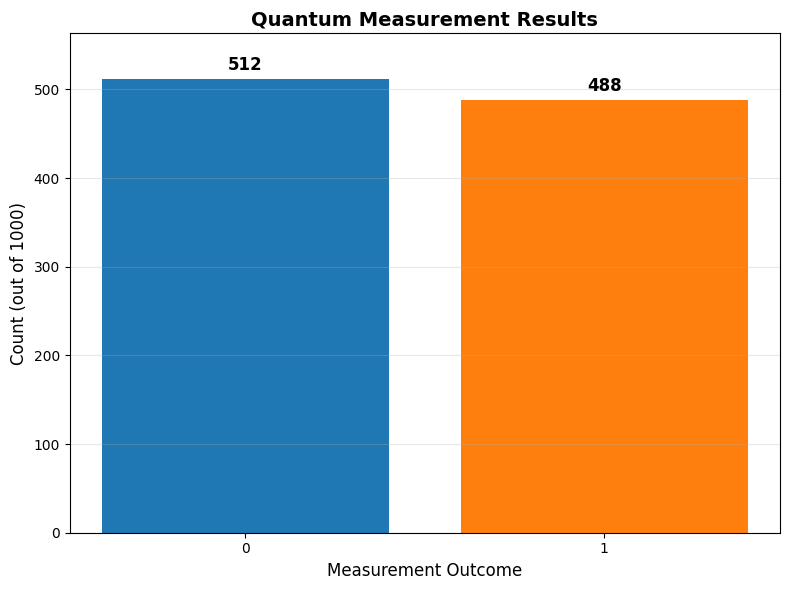

In [ ]:
states=list(counts.keys())
values=list(counts.values())

plt.figure(figsize=(8, 6))
plt.bar(states, values, color=['#1f77b4', '#ff7f0e'])
plt.xlabel('Measurement Outcome', fontsize=12)
plt.ylabel('Count (out of 1000)', fontsize=12)
plt.title('Quantum Measurement Results', fontsize=14, fontweight='bold')
plt.ylim(0, max(values)*1.1)

for i, (state, value) in enumerate(zip(states, values)):
  plt.text(i, value+10, str(value), ha='center', fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Qiskit Machine Learning
* Installs the Qiskit Machine Learning library from the Python Package Index (PyPI).
* This library provides high-level tools for building, training and deploying quantum machine learning models.
 **What the package contains**
 * The `qiskit-machine-learning` package extends Qiskit with ML-specific features including:
  * Quantum Neural Networks (QNNs): Implementations of parameterized quantum circuits used for classification and regression.
  * Neural Network Interfaces: Classes like `EstimatorQNN`, `SamplerQNN`, and `OpflowQNN` for bridging between quantum models and classical ML frameworks.
  * Quantum Kernel Methods: Used in Quantum Support Vector Machines (QSVMs) and Kernel Ridge Regression.
  * Torch and Scikit-learn Integration: Enables hybrid workflows combinig PyTorch, TensorFlow, or scikit-learn with quantum backends.

In [ ]:
!pip install qiskit-machine-learning

### Import Libraries and tools
1. `from qiskit.circuit import Parameter`
* `Parameter` is a symbolic variable used in parameterized quantum circuits (also called variational circuits).
* Instead of hardcoding numeric values into a quantum gate, we can define a parameter (like $$\theta, \phi,\lambda$$) and later substitute different values--e.g., during training.

* `Parameter` enables differentiable, trainable quantum circuits.

2. `from qiskit.circuit.library import RealEmplitudes, ZZFeatureMap`
* Both of these are predefined circuit templates from Qiskit's library that simplify QML development:

  **`ZZFeatureMap`**
  * Used for data encoding (feature mapping), the process of embedding classical input data into quantum states.
  * It uses entangling ZZ interactions between qubits to represent correlations between features.
  * The mathematical form is:
  $$
  U_{\phi}=exp(i\sum_{i,j} \phi_{ij} (x_i, x_j)Z_iZ_j)
  $$

  **`RealAmplitudes`**
  * A variational ansatz, a parameterized quantum circuit that represents the trainable model in QML.
  * It consists of layers of rotationa gates (Ry, Rz) and entangling CNOT gates.
  * The parameters of this circuit (the rotation angles) are adjusted during training to minimize a loss function.

* In a quantum ML pipeline, these components are typically combined as:
  1. `ZZFeatureMap`-> encodes classical data into a quantum state/
  2. `RealAmplitudes`-> Applies trainable transformations to that state.
  3. Measurement-> Extracts information for classification or regression tasks.

In [ ]:
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap

### Optimization Step
* The minimize function from SciPy's optimization library is a general classical optimizer used to find the minimum value of a cost (objective) function.

* In the context of QML, it's used to train te parameters of a parameterized quantum circuit by minimizing a loss function that measures prediction error or energy.

In [ ]:
#For optimization
from scipy.optimize import minimize

### XOR dataset
1. **`X_train`-Input features**
* This defines a 2D input space, two binary features per sample.
* There are four possible input combinations for two binary variables.

2. **`y_train`- Output labels**
* This defines the target output (labels) for each input pair according to the XOR table.

In [ ]:
#XOR dataset
X_train=np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_train=np.array([0, 1, 1, 0])

### XOR truth table
* This cell prints the XOR truth table in a clear format, confirming that the dataset is correctly represented in the logic function the models will attemot to learn from.

In [ ]:
print("Input A | Input B | Output")
for i in range(len(X_train)):
  print(f"{X_train[i][0]} | {X_train[i][1]} | {y_train[i]}")

Input A | Input B | Output
0 | 0 | 0
0 | 1 | 1
1 | 0 | 1
1 | 1 | 0


### XOR visual
* This visualization illustrates the XOR problem's nonlinearity.

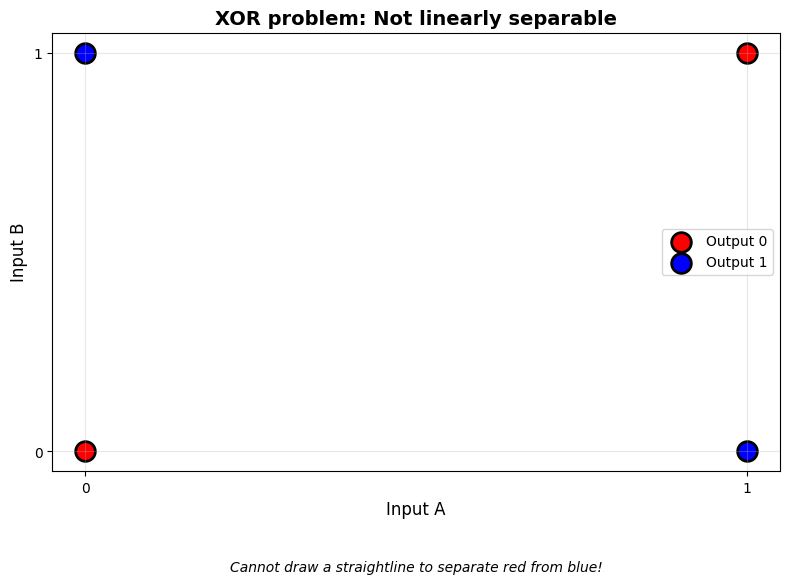

In [ ]:
plt.figure(figsize=(8, 6))
colors=['red', 'blue']
for i in range(len(X_train)):
  plt.scatter(X_train[i][0], X_train[i][1],
              c=colors[y_train[i]], s=200,
              edgecolors='black', linewidth=2,
              label=f'Output {y_train[i]}' if i<2 else'')

plt.xlabel('Input A', fontsize=12)
plt.ylabel('Input B', fontsize=12)
plt.title("XOR problem: Not linearly separable", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.text(0.5, -0.3, 'Cannot draw a straightline to separate red from blue!',
         ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.show()

### Classical Neural Network Setup
* This section defines a simple feedforward neural network built from scratch using only NumPY, designed to learn the XOR logical function.

**Class Definition**
* The `ClassicalNN` class implements a two-layer neural network:
  * Input layer: 2 neurons (for the XOR inputs).
  * Hidden layer: 4 neurons (allows for non-linear separation).
  * Output layer: 1 neuron (binary output).

**Initialization**
* Random weights ensure variation but reproducible results (`seed=42`).
* `W1` and `W2` connect input-> hidden and hidden-> output layers respectively.
* Biases are initalized to zero.

**Activation Function**
* Sigmoid activation adds nonlinearity, crucial for solving XOR.
* `np.clip` prevents overflow errors during large exponentiation.

**Forward pass**
* Propagates input `X` trough the layers.
* Stores intermediate activations (`z1`, `a1`, e.t.c.) for backpropagation.

**Training**
* Performs gradient descent to minimize mean squared error (MSE).
* Steps inside:
  1. **Forward pass**: Compute output.
  2. **Compute loss**: $$ MSE=\frac {1}{m} \sum(y_{pred}-y_{true})^2 $$
  3. **Backward pass**: Derive gradients using chain rule.
  4. **Update weights and biases**:
  $$ W=W-learning rate x gradient$$
  5. **Print progress every 200 epochs.**

**Output**
* The network prints loss updates.
* This forms the classical baseline to later compare with a quantum neural network.



In [ ]:
class ClassicalNN:
  """Simple 2-layer neural network for XOR"""
  def __init__(self):
    #Initialize weights randomly
    np.random.seed(42) # Corrected typo here
    self.W1=np.random.randn(2, 4)*0.5 #input to hidden (2-> 4 neurons)
    self.b1=np.zeros(4)
    self.W2=np.random.randn(4, 1)*0.5 #hidden to output (4-> 1)
    self.b2=np.zeros(1)

  def sigmoid(self, x):
    return 1/ (1+np.exp(-np.clip(x, -500, 500)))

  def forward(self, X):
    """Forward pass"""
    self.z1=X @ self.W1+self.b1
    self.a1=self.sigmoid(self.z1)
    self.z2=self.a1 @ self.W2+self.b2
    self.a2=self.sigmoid(self.z2)
    return self.a2

  def train(self, X, y, epochs=1000, lr=0.5):
    """Train using gradient descent"""
    losses=[]
    for epoch in range(epochs):
      #Forward pass
      output=self.forward(X)

      #Compute loss (MSE)
      loss=np.mean((output.flatten()-y)**2)
      losses.append(loss)

      #Backward pass (simplified)
      m=X.shape[0]
      dz2=(output.flatten()-y).reshape(-1, 1)
      dW2=(self.a1.T @ dz2)/m
      db2=np.sum(dz2)/m # Corrected the typo here

      da1=dz2 @ self.W2.T
      dz1=da1*self.a1*(1-self.a1)
      dW1=(X.T @ dz1)/m
      db1=np.sum(dz1, axis=0)/m

      #Update weights
      self.W1-=lr*dW1
      self.b1-=lr*db1
      self.W2-=lr*dW2
      self.b2-=lr*db2

      if epoch%200==0:
        print(f'Epoch {epoch}: Loss={loss:.4f}')

    return losses

### Training the Classical-NN
* After defining the `ClassicalNN` class, we now instantiate and train the model on the XOR data.

**Model Initialization**
`classical_nn=ClassicalNN()`
* Creates an instance of our neural network with:
  * Randomly initialized weights (`W1`, `W2`).
  * Zero biases (`b1`, `b2`).
* The network is ready to learn the XOR mapping.

**Model Training**
`classical_losses=classical_nn.train(X_train, y_train, epochs=5000)`
* The models trains for 5000 iterations. `(epochs=5000)`
* `lr=0.5`(Default learning rate from class) controls how much the weights are adjusted each step.

* Each epoch performs:
  1. **Forward pass**: Predicts output for all 4 XOR inputs.
  2. **Loss computation**: Uses Mean Squared Error (MSE) to measure prediction error.
  3. **Backward pass**: Calculates gradients via the chain rule.
  4. **Weight update**: Adjusts `W1`, `b1`, `W2`, and `b2` to minimize loss.

In [ ]:
classical_nn=ClassicalNN()
classical_losses=classical_nn.train(X_train, y_train, epochs=5000)

Epoch 0: Loss=0.2557
Epoch 200: Loss=0.2500
Epoch 400: Loss=0.2498
Epoch 600: Loss=0.2493
Epoch 800: Loss=0.2440
Epoch 1000: Loss=0.2019
Epoch 1200: Loss=0.1208
Epoch 1400: Loss=0.0272
Epoch 1600: Loss=0.0049
Epoch 1800: Loss=0.0017
Epoch 2000: Loss=0.0008
Epoch 2200: Loss=0.0004
Epoch 2400: Loss=0.0003
Epoch 2600: Loss=0.0002
Epoch 2800: Loss=0.0001
Epoch 3000: Loss=0.0001
Epoch 3200: Loss=0.0001
Epoch 3400: Loss=0.0001
Epoch 3600: Loss=0.0001
Epoch 3800: Loss=0.0000
Epoch 4000: Loss=0.0000
Epoch 4200: Loss=0.0000
Epoch 4400: Loss=0.0000
Epoch 4600: Loss=0.0000
Epoch 4800: Loss=0.0000


### Model evaluation and Prediction
* After training the classical neural network, this cell evaluates how well it learned the XOR logic by performing predictions on the training data and printing results in an interpretable way.

**`prediction=classical_nn.forward(X_train)`**
* Perfoms a forward pass on the trained network.
* **`forward()`** applies:
  1. Linear combination- `z1=X @ W1 +b1`
  2. Sigmoid activation- `a1`.
  3. Second linear combination- `z2=a1 @ W2 + b2`.
  4. Sigmoid activation- `a2` which is the final output.
* Returns a 4x1 array of predicted probabilities between 0 and 1.

`**for i in ranga(len(X_train))**`
* Iterates over all four training examples.

`**pred=prediction[i][0]**`
* Extracts the scalar prediction for each sample (since each row is a 1-element array).

* Displays the input pair, the predicted probability, the rounded binary output, and the true label `y_train`.

In [ ]:
prediction=classical_nn.forward(X_train)
for i in range(len(X_train)):
  pred=prediction[i][0]
  print(f"Input: {X_train[i]}-> Prediction: {pred:.4f}-> Rounded: {int(pred>0.5)} (True: {y_train[i]})")

Input: [0 0]-> Prediction: 0.0059-> Rounded: 0 (True: 0)
Input: [0 1]-> Prediction: 0.9960-> Rounded: 1 (True: 1)
Input: [1 0]-> Prediction: 0.9960-> Rounded: 1 (True: 1)
Input: [1 1]-> Prediction: 0.0035-> Rounded: 0 (True: 0)


### Quantum Model Parameters
* `n_qubits=2`
* Defines the number of qubits in the quantum circuit that will represet and process the input data.
* Since the XOR dataset has 2 input features (`Input A` and `Input B`), using 2 qubits is fair, one qubit per feature.
* This allows the quantum feature map to encode both inputs into quantum states, capturing possible quantum correlations (entanglement) between them.

**Conceptual Background**
Each qubit represents one dimension (or feature) of the classical input. Quantum gates (like those in the feature map and variational layers) manipulate these qubits to form complex, high-dimensional quantum states. The quantum measurement results are used to approximate the decision boundary, similar to how classical neurons learn nonlinear mappings.

In [ ]:
n_qubits=2
print(f"\nUsing {n_qubits} qubits for our QNN")


Using 2 qubits for our QNN


### Building the Quantum Feature Map
This cell defines how classical data (the XOR inputs) are encoded into quantum states.

**Step-by-step explanation**
`ZZFeatureMap(feature_dimension=2, reps=1)`
* Creates a feature map circuit using Qiskit's built in `ZZFeatureMap` class.
* The feature map is a data encoding layer that transforms classical features into quantum states.

**Parameters**:

* `feature_dimension=2`: Number of classical features (XOR has 2--matches our `n_qubits=2`

* `reps=1`: Number of repeated encoding layers; more reps, deeper circuit and highe expressivity.

This means:
* Each XOR input `[x1, x2]` is encoded into 2 qubits.
* The circuit applies rotations and entangling gates that represent these features as quantum states.

* `print(feature_map.decompose().draw(output='text))`
* `decompose()` expands any composite gates into ther basic building blocks (e.g., `rz`, `cx`, etc.), making the full structure visible.
* `draw(output='text')` prints an ASCII-art visualization of the quantum circuit.

**Conceptual Backgorund**
The `ZZFeatureMap` is designed to capture both individual features and their correlations.
* It performs:
  1. **Rotation encoding**: Each input feature `xi` is encoded via a `RZ` rotation on qubit *i*.
  2. **Entanglement**: Applies controled-`ZZ` interactions (`exp(-i Zx z x_i x_j)`) between qubits.
    * This introduces feature interaction--a key part of why quantum ciruits can learn nonlinear relationships like XOR.

  So mathematically, it encodes:
  $$ |ϕ(x) \rangle=U_{ZZ}(x)|0\rangle $$
  where `U_{ZZ}` represents the feature-dependent rotation and entanglement operations.


In [ ]:
feature_map=ZZFeatureMap(feature_dimension=2, reps=1)
print(feature_map.decompose().draw(output='text'))

     ┌───┐┌─────────────┐                                          
q_0: ┤ H ├┤ P(2.0*x[0]) ├──■────────────────────────────────────■──
     ├───┤├─────────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐
q_1: ┤ H ├┤ P(2.0*x[1]) ├┤ X ├┤ P(2.0*(π - x[0])*(π - x[1])) ├┤ X ├
     └───┘└─────────────┘└───┘└──────────────────────────────┘└───┘


In [ ]:
ansatz=RealAmplitudes(n_qubits, reps=2)
print(ansatz.decompose().draw(output='text'))

     ┌──────────┐     ┌──────────┐     ┌──────────┐
q_0: ┤ Ry(θ[0]) ├──■──┤ Ry(θ[2]) ├──■──┤ Ry(θ[4]) ├
     ├──────────┤┌─┴─┐├──────────┤┌─┴─┐├──────────┤
q_1: ┤ Ry(θ[1]) ├┤ X ├┤ Ry(θ[3]) ├┤ X ├┤ Ry(θ[5]) ├
     └──────────┘└───┘└──────────┘└───┘└──────────┘


In [ ]:
def create_qnn_circuit(n_qubits):
  """Create the complet QNN circuit"""
  # Initialize qc with the correct number of qubits
  qc=QuantumCircuit(n_qubits)

  #Feature map (data encoding)
  feature_map=ZZFeatureMap(feature_dimension=2, reps=1)

  #Variational form (trainable part)
  ansatz=RealAmplitudes(n_qubits, reps=2)

  #Combine
  qc.compose(feature_map, inplace=True)
  qc.compose(ansatz, inplace=True)
  return qc, feature_map.num_parameters, ansatz.num_parameters

In [ ]:
qnn_circuit, n_features, n_params=create_qnn_circuit(n_qubits)
print(qnn_circuit.decompose().draw(output='text'))

     ┌───┐┌─────────────┐                                          ┌──────────┐»
q_0: ┤ H ├┤ P(2.0*x[0]) ├──■────────────────────────────────────■──┤ Ry(θ[0]) ├»
     ├───┤├─────────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐├──────────┤»
q_1: ┤ H ├┤ P(2.0*x[1]) ├┤ X ├┤ P(2.0*(π - x[0])*(π - x[1])) ├┤ X ├┤ Ry(θ[1]) ├»
     └───┘└─────────────┘└───┘└──────────────────────────────┘└───┘└──────────┘»
«          ┌──────────┐     ┌──────────┐
«q_0: ──■──┤ Ry(θ[2]) ├──■──┤ Ry(θ[4]) ├
«     ┌─┴─┐├──────────┤┌─┴─┐├──────────┤
«q_1: ┤ X ├┤ Ry(θ[3]) ├┤ X ├┤ Ry(θ[5]) ├
«     └───┘└──────────┘└───┘└──────────┘


In [ ]:
simulator=AerSimulator()

In [ ]:
def quantum_forward(x_input, params):
  """
  Forward pass through the quantum circuit

  Args:
    x_input: Input data [x1, x2]
    params: Trainable parameters

  Returns:
    expectation value (our prediction)
  """
  #Create circuit
  qc, n_feat, n_par=create_qnn_circuit(n_qubits)

  #Bind parameters
  all_params=list(x_input)+list(params)
  param_dict={p: all_params[i] for i, p in enumerate(qc.parameters)}
  bound_qc=qc.assign_parameters(param_dict)

  #Add measurement in Z basis
  bound_qc.measure_all()

  #Run simulation
  compiled=transpile(bound_qc, simulator)
  job=simulator.run(compiled, shots=1000)
  counts=job.result().get_counts()

  #Calculate expectation value
  expectation=0
  total_shots=sum(counts.values())
  for bitstring, count in counts.items():
    #Count number of 1s in the bitstring
    parity=bitstring.count('1')%2 #even=0, odd=1
    sign=1 if parity == 0 else -1
    expectation+=sign* count/ total_shots

  #Map from [-1, 1] to [0, 1]
  return (expectation+1)/2

In [ ]:
test_params=np.random.randn(n_params)*0.5
test_output=quantum_forward(X_train[0], test_params)
print(f"Input: {X_train[0]}-> Output: {test_output:4f}")

Input: [0 0]-> Output: 0.649000


In [ ]:
def qnn_loss(params, X, y):
  """Calculate loss for the QNN"""
  predictions=[]
  for x in X:
    pred=quantum_forward(x, params)
    predictions.append(pred)
  predictions=np.array(predictions)

  #Mean Squared Error
  loss=np.mean((predictions-y)**2)
  return loss

In [ ]:
def train_qnn(X,y, epochs=50, initial_params=None):
  """Train the QNN using classical optimizer"""
  if initial_params is None:
    params=np.random.randn(n_params)*0.1
  else:
    params=initial_params

  losses=[]

  for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}...")

    #Calculate loss
    loss=qnn_loss(params, X, y)
    losses.append(loss)
    print(f"Loss: {loss:.4f}")

    #Gradient-based optimization step
    result=minimize(qnn_loss, params, args=(X, y),
                    method='COBYLA',
                    options={'maxiter':50})

    params=result.x

    #Show predictions
    if (epoch+1)%3==0 or epoch==0:
      print("Current predictions:")
      for i in range(len(X)):
        pred=quantum_forward(X[i], params)
        print(f"{X[i]}->{pred:.4f} (True: {y[i]})")

  return params, losses

In [ ]:
initial_params=np.random.randn(n_params)*0.1

trained_params, qnn_losses=train_qnn(X_train, y_train, epochs=5,
                                     initial_params=initial_params)

Epoch 1/5...
Loss: 0.2805
Current predictions:
[0 0]->0.0260 (True: 0)
[0 1]->0.7150 (True: 1)
[1 0]->0.7470 (True: 1)
[1 1]->0.4500 (True: 0)
Epoch 2/5...
Loss: 0.0816
Epoch 3/5...
Loss: 0.0918
Current predictions:
[0 0]->0.0420 (True: 0)
[0 1]->0.8080 (True: 1)
[1 0]->0.7230 (True: 1)
[1 1]->0.4960 (True: 0)
Epoch 4/5...
Loss: 0.0865
Epoch 5/5...
Loss: 0.0848


In [ ]:
for i in range(len(X_train)):
  pred=quantum_forward(X_train[i], trained_params)
  rounded=int(pred>0.5)
  correct="-/" if rounded==y_train[i] else"x"
  print(f"Input: {X_train[i]}-> Pred: {pred:.4f}-> Rounded: {rounded} (True: {y_train[i]}) {correct}")

Input: [0 0]-> Pred: 0.0280-> Rounded: 0 (True: 0) -/
Input: [0 1]-> Pred: 0.7690-> Rounded: 1 (True: 1) -/
Input: [1 0]-> Pred: 0.7810-> Rounded: 1 (True: 1) -/
Input: [1 1]-> Pred: 0.4710-> Rounded: 0 (True: 0) -/


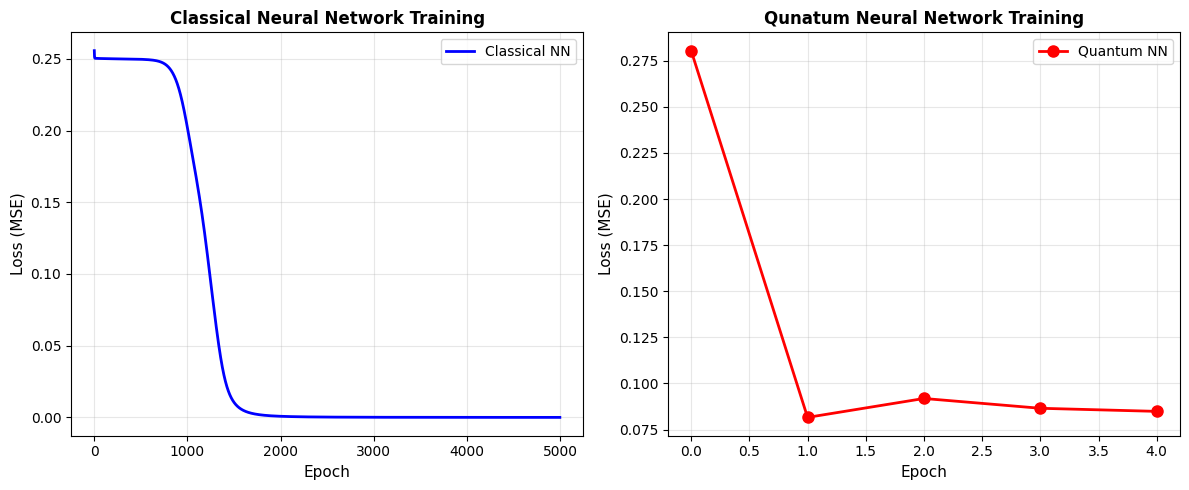

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(classical_losses, 'b-', linewidth=2, label='Classical NN')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss (MSE)', fontsize=11)
plt.title('Classical Neural Network Training', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(len(qnn_losses)), qnn_losses, color='r', linestyle='-', linewidth=2,
         marker='o', markersize=8, label='Quantum NN')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss (MSE)', fontsize=11)
plt.title('Qunatum Neural Network Training', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()